## EXPLORATORY DATA ANALYSIS(EDA)

In [1]:
import pandas as pd
import numpy as np
import re
from langdetect import detect
from textblob import TextBlob
import nltk
import unicodedata
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from rake_nltk import Rake
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models
import spacy
from sqlalchemy import create_engine, text
import os

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("scored_reviews.csv")
print(df.groupby("bank")["sentiment_combined"].value_counts(normalize=True).unstack().fillna(0))

sentiment_combined   -0.9272   -0.9205   -0.9107   -0.8979   -0.8834  \
bank                                                                   
BOA                 0.000000  0.000000  0.009901  0.000000  0.009901   
CBE                 0.000000  0.000000  0.000000  0.010753  0.000000   
Dashen              0.008065  0.008065  0.000000  0.000000  0.000000   

sentiment_combined   -0.8491   -0.8466   -0.8304   -0.8126   -0.8122  ...  \
bank                                                                  ...   
BOA                 0.009901  0.000000  0.000000  0.009901  0.000000  ...   
CBE                 0.000000  0.010753  0.010753  0.000000  0.000000  ...   
Dashen              0.000000  0.000000  0.000000  0.000000  0.008065  ...   

sentiment_combined    0.9186    0.9306    0.9336    0.9357    0.9524  \
bank                                                                   
BOA                 0.000000  0.000000  0.000000  0.000000  0.000000   
CBE                 0.000000  0.00000

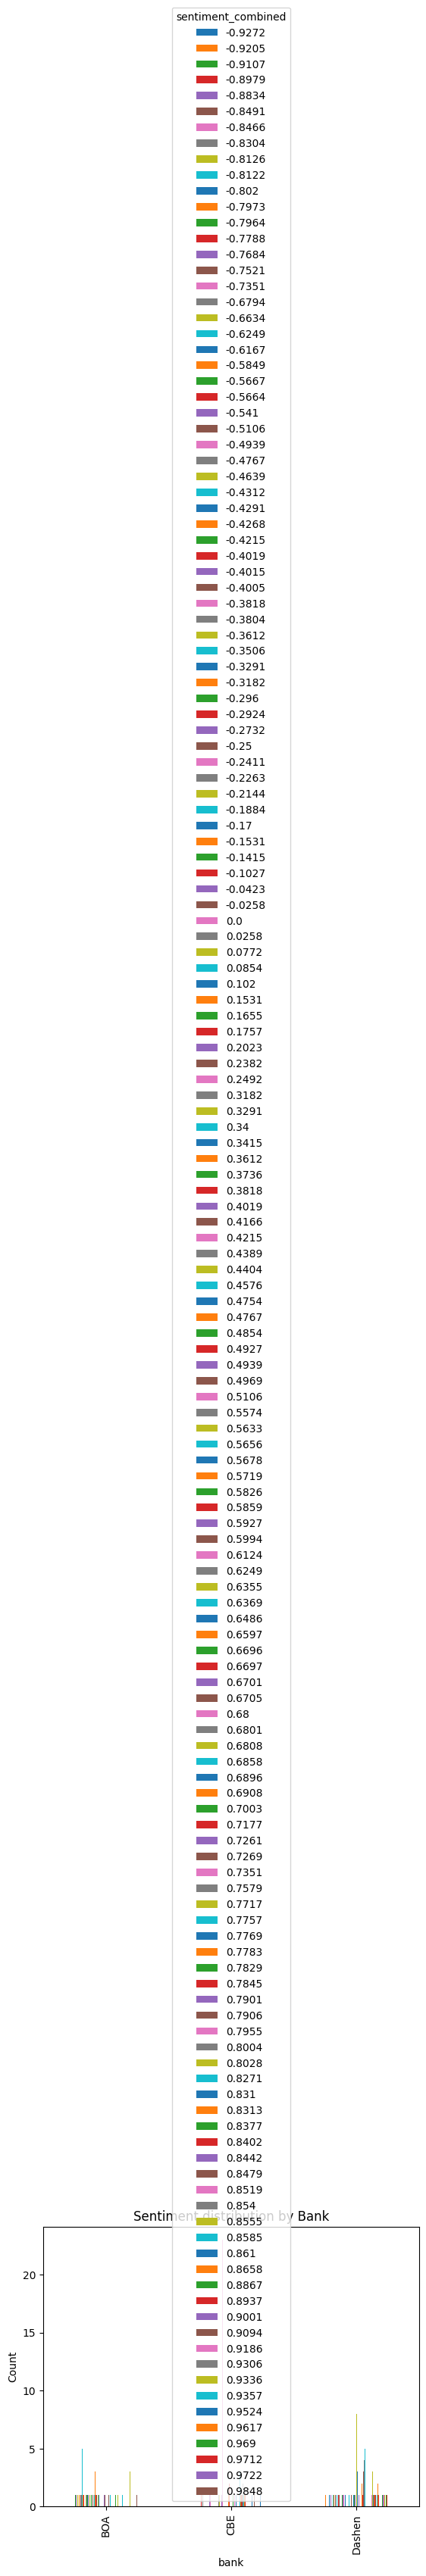

In [4]:
sent_counts = df.groupby(["bank","sentiment_combined"]).size().unstack(fill_value=0)
sent_counts.plot(kind='bar', stacked=False)
plt.title("Sentiment distribution by Bank")
plt.ylabel("Count")
plt.show()

In [5]:
print(df.groupby("bank")["score"].agg(["count","mean","median"]))

        count      mean  median
bank                           
BOA       101  2.683168     2.0
CBE        93  3.913978     5.0
Dashen    124  3.935484     5.0


In [6]:
def extract_nouns(text):
    blob = TextBlob(text)
    return [word for word, tag in blob.tags if tag.startswith('NN')]

df['nouns'] = df['content_clean'].apply(extract_nouns)

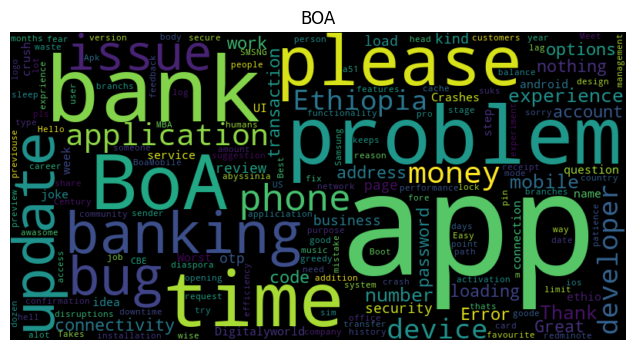

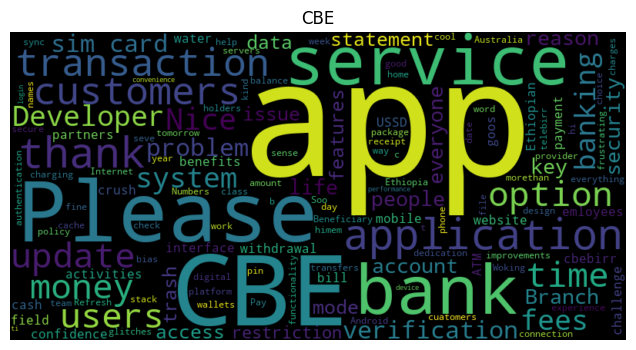

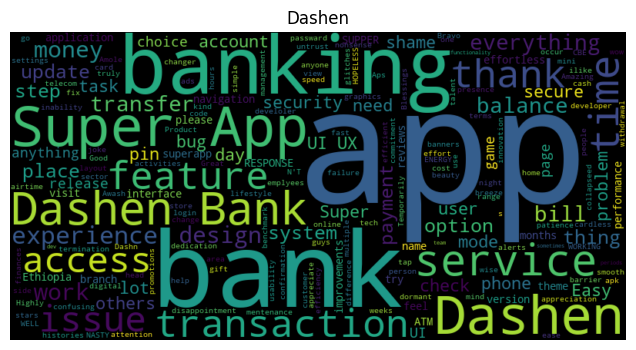

In [7]:
from wordcloud import WordCloud
for bank in df["bank"].unique():
    text = " ".join(sum(df[df["bank"]==bank]["nouns"].apply(lambda x: eval(x) if isinstance(x,str) and x.startswith('[') else x).tolist(), []))
    wc = WordCloud(width=800, height=400).generate(text)
    plt.figure(figsize=(10,4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(bank)
    plt.show()